In [1]:
!pip install uproot
import uproot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.5/397.5 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.8/925.8 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.3/689.3 kB 34.3 MB/s eta 0:00:00


In [11]:
!pip install awkward
import awkward as ak

In [15]:
!pip install awkward_pandas

standard PET - two-gamma anhilation

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import awkward as ak

rootfile = uproot.open('merged.root')
print(rootfile.keys())

['TwoG_NCS;1', 'TwoG_PhantomSCS;1', 'TwoG_ScannerSCS;1', 'TwoG_PhantomSCS_ScannerSCS;1', 'TwoG_PhantomDCS;1', 'TwoG_ScannerDCS;1', 'TwoG_PhantomSCS_ScannerDCS;1', 'TwoG_PhantomDCS_ScannerSCS;1', 'TwoG_PhantomDCS_ScannerDCS;1', 'TwoG_MCS;1', 'TwoG_Excluded;1', 'ThreeG_NCS;1', 'ThreeG_ScannerSCS;1', 'ThreeG_ScannerDCS;1', 'ThreeG_ScannerTCS;1', 'ThreeG_MCS;1', 'ThreeG_Excluded;1']


In [5]:
for key in rootfile.keys():
    obj = rootfile[key]
    if hasattr(obj, "num_entries"):
        print(key, obj.num_entries)

TwoG_NCS;1 42062
TwoG_PhantomSCS;1 26934
TwoG_ScannerSCS;1 136764
TwoG_PhantomSCS_ScannerSCS;1 56968
TwoG_PhantomDCS;1 3312
TwoG_ScannerDCS;1 99240
TwoG_PhantomSCS_ScannerDCS;1 24520
TwoG_PhantomDCS_ScannerSCS;1 4225
TwoG_PhantomDCS_ScannerDCS;1 1506
TwoG_MCS;1 547171
TwoG_Excluded;1 0
ThreeG_NCS;1 0
ThreeG_ScannerSCS;1 0
ThreeG_ScannerDCS;1 0
ThreeG_ScannerTCS;1 0
ThreeG_MCS;1 0
ThreeG_Excluded;1 0


In [26]:
tree = rootfile['TwoG_ScannerSCS']
print(tree.keys())

['EventID', 'CoincidenceType', 'CoincidenceTypeName', 'NGammas', 'AnnihilX_mm', 'AnnihilY_mm', 'AnnihilZ_mm', 'GammaIndex', 'GammaTrackID', 'GammaParentID', 'HitIndex', 'VolumeID', 'VolumeName', 'ProcessID', 'ProcessName', 'EnergyDeposit_keV', 'PreEnergy_keV', 'PostEnergy_keV', 'X_mm', 'Y_mm', 'Z_mm', 'Theta_deg', 'Phi_deg', 'DeltaPhi01_deg', 'DeltaPhi02_deg', 'DeltaPhi12_deg']


In [16]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt

filename = "merged.root"
tree_name = "TwoG_NCS"

file = uproot.open(filename)
tree = file[tree_name]

df = tree.arrays(library="pd")

print(df.head())
print(df.columns)

   EventID  CoincidenceType  CoincidenceTypeName  NGammas  AnnihilX_mm  \
0       14                0             TwoG_NCS        2    -0.569898   
1       14                0             TwoG_NCS        2    -0.569898   
2       18                0             TwoG_NCS        2     3.877718   
3       18                0             TwoG_NCS        2     3.877718   
4       26                0             TwoG_NCS        2     2.400055   

   AnnihilY_mm  AnnihilZ_mm  GammaIndex  GammaTrackID  GammaParentID  ...  \
0     2.368709    -5.295002           0             3              1  ...   
1     2.368709    -5.295002           1             2              1  ...   
2     4.785067    -7.613710           0             3              1  ...   
3     4.785067    -7.613710           1             2              1  ...   
4    -0.319345   -12.199783           0             3              1  ...   

   PreEnergy_keV  PostEnergy_keV       X_mm       Y_mm       Z_mm  Theta_deg  \
0     510.99

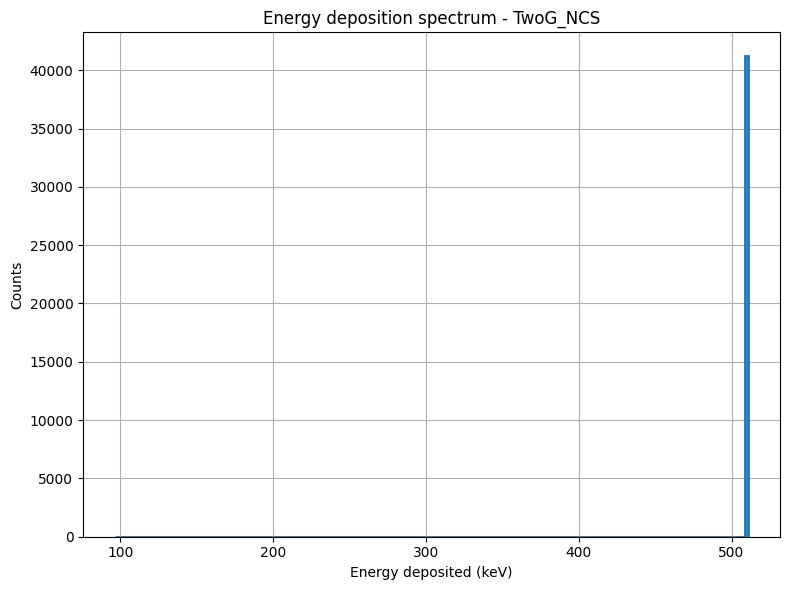

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.hist(df["EnergyDeposit_keV"],
         bins=200,
         histtype="step",
         linewidth=2)

plt.xlabel("Energy deposited (keV)")
plt.ylabel("Counts")
plt.title("Energy deposition spectrum - TwoG_NCS")

plt.grid(True)

plt.tight_layout()
plt.show()

this is expected as there is no scattering - dummy check that the simulation has worked

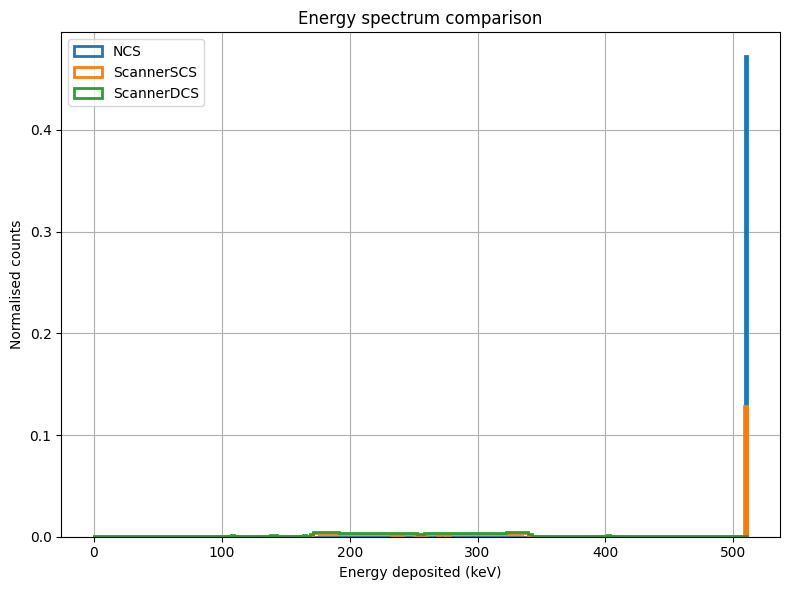

In [20]:
tree1 = file["TwoG_NCS"].arrays(library="pd")
tree2 = file["TwoG_ScannerSCS"].arrays(library="pd")
tree3 = file["TwoG_ScannerDCS"].arrays(library="pd")

plt.figure(figsize=(8,6))

plt.hist(tree1["EnergyDeposit_keV"],
         bins=200,
         histtype="step",
         linewidth=2,
         density=True,
         label="NCS")

plt.hist(tree2["EnergyDeposit_keV"],
         bins=200,
         histtype="step",
         linewidth=2,
         density=True,
         label="ScannerSCS")

plt.hist(tree3["EnergyDeposit_keV"],
         bins=200,
         histtype="step",
         linewidth=2,
         density=True,
         label="ScannerDCS")

plt.xlabel("Energy deposited (keV)")
plt.ylabel("Normalised counts")
plt.title("Energy spectrum comparison")

plt.legend()

plt.grid(True)

plt.tight_layout()
plt.show()

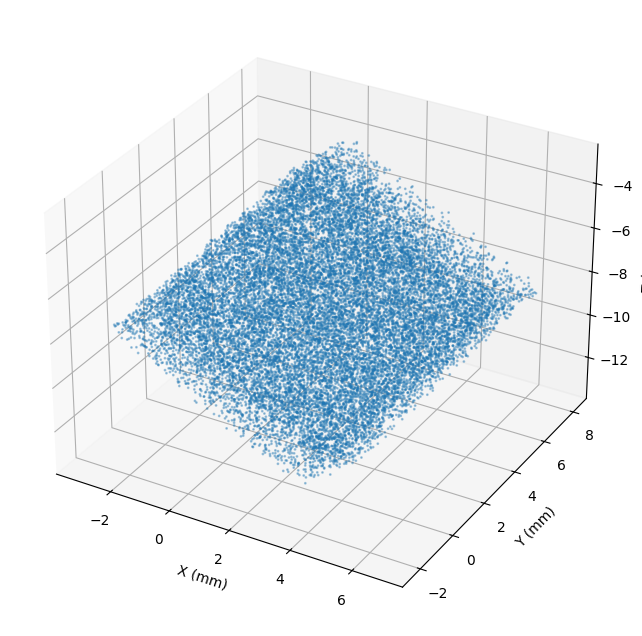

In [24]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

treeSCS = file["TwoG_ScannerSCS"]

data = tree.arrays(library="pd")

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(data["AnnihilX_mm"],
           data["AnnihilY_mm"],
           data["AnnihilZ_mm"],
           s=1,
           alpha=0.2)

ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_zlabel("Z (mm)")

plt.show()

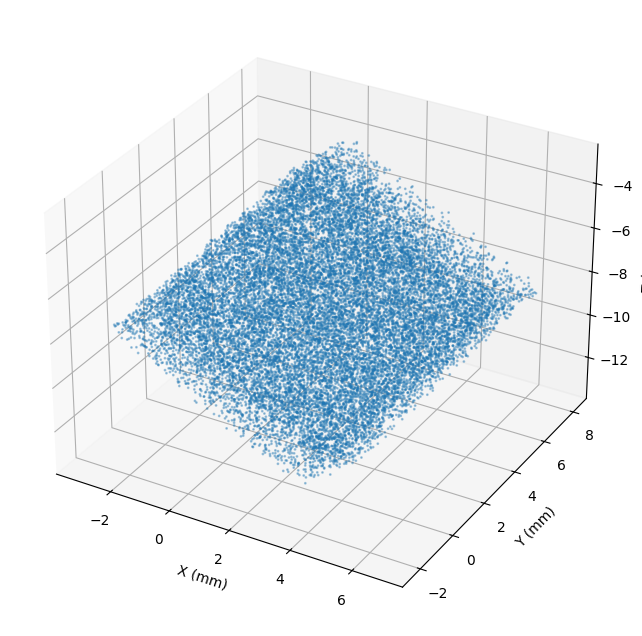

In [25]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

treeDCS = file["TwoG_ScannerDCS"]

data = tree.arrays(library="pd")

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(data["AnnihilX_mm"],
           data["AnnihilY_mm"],
           data["AnnihilZ_mm"],
           s=1,
           alpha=0.2)

ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_zlabel("Z (mm)")

plt.show()

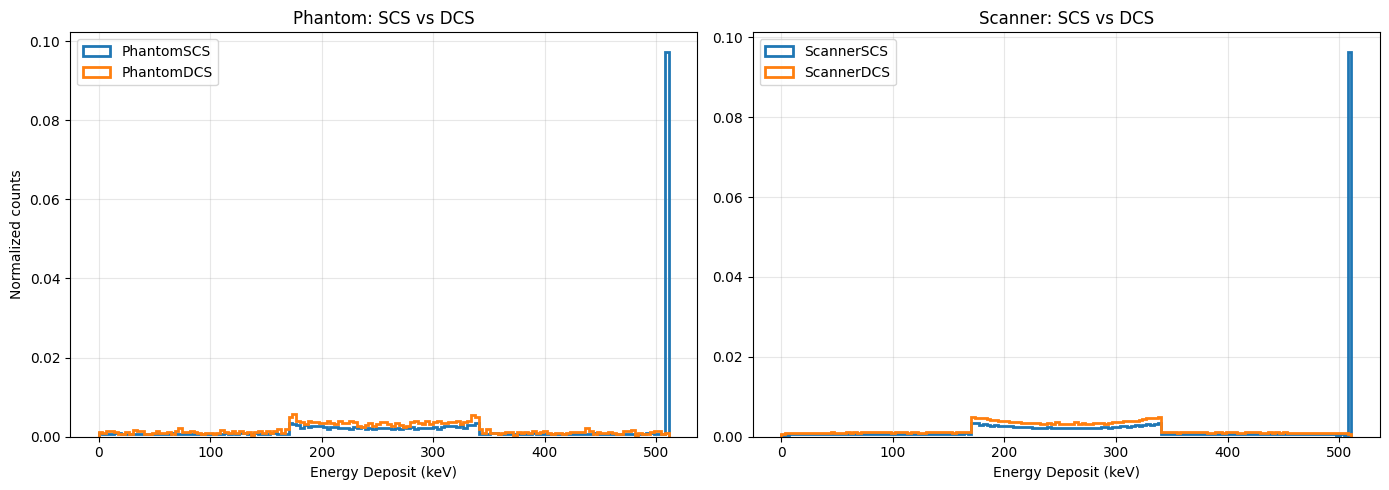

In [28]:
#energu deposit spectra
dfs = {
    "PhantomSCS": file["TwoG_PhantomSCS"].arrays(library="pd"),
    "PhantomDCS": file["TwoG_PhantomDCS"].arrays(library="pd"),
    "ScannerSCS": file["TwoG_ScannerSCS"].arrays(library="pd"),
    "ScannerDCS": file["TwoG_ScannerDCS"].arrays(library="pd")
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name in ["PhantomSCS", "PhantomDCS"]:
    axes[0].hist(dfs[name]["EnergyDeposit_keV"], bins=150, histtype="step",
                 density=True, linewidth=2, label=name)
axes[0].set_xlabel("Energy Deposit (keV)")
axes[0].set_ylabel("Normalized counts")
axes[0].set_title("Phantom: SCS vs DCS")
axes[0].legend()
axes[0].grid(alpha=0.3)

for name in ["ScannerSCS", "ScannerDCS"]:
    axes[1].hist(dfs[name]["EnergyDeposit_keV"], bins=150, histtype="step",
                 density=True, linewidth=2, label=name)
axes[1].set_xlabel("Energy Deposit (keV)")
axes[1].set_title("Scanner: SCS vs DCS")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

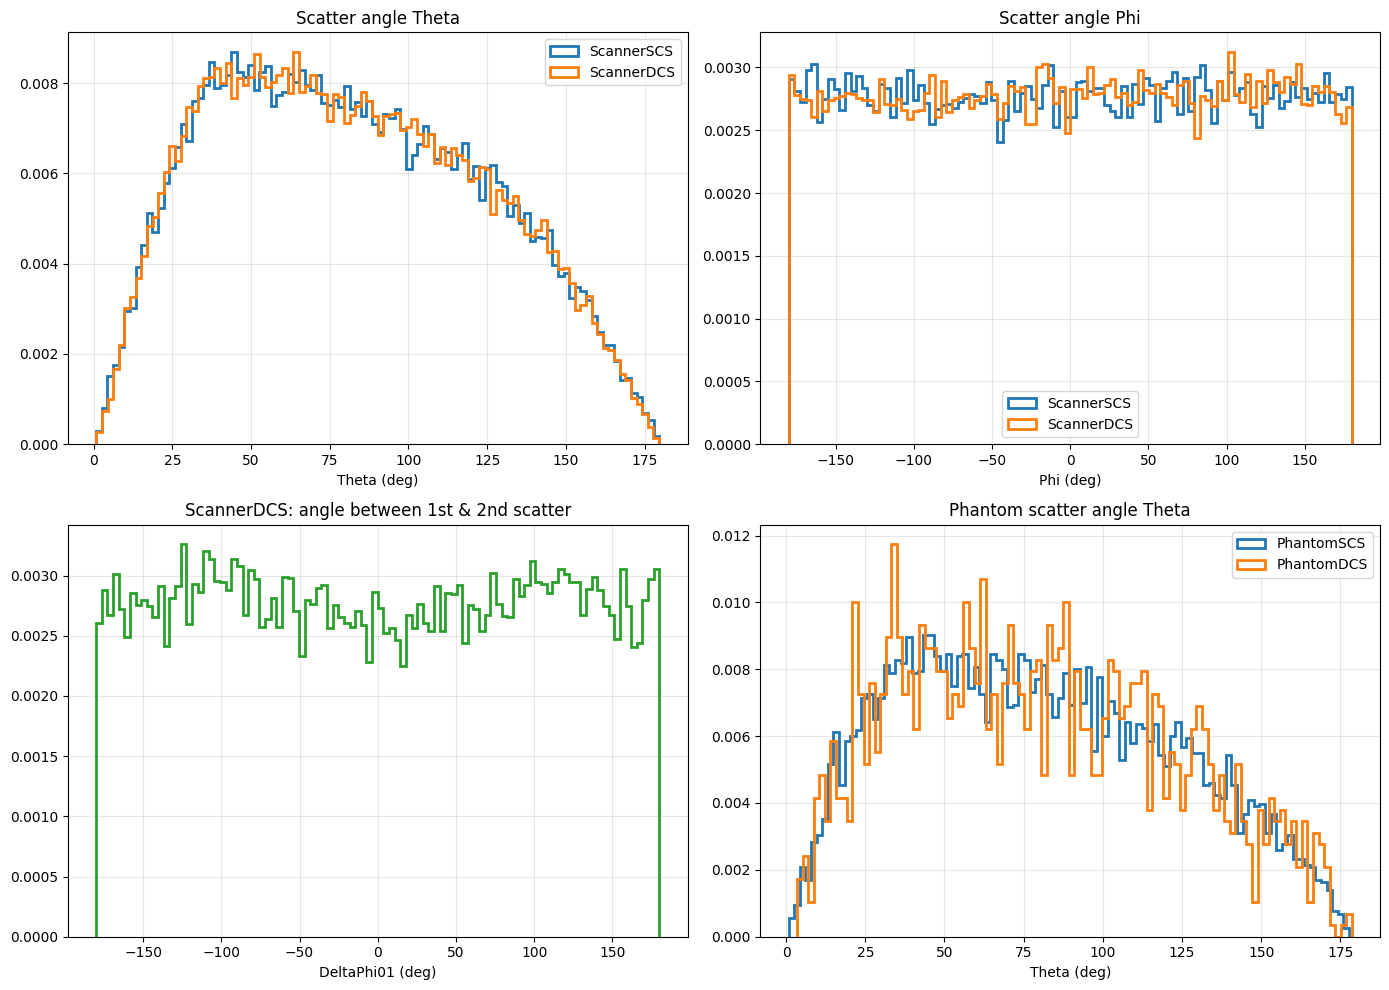

In [29]:
# scatterig angle distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for name in ["ScannerSCS", "ScannerDCS"]:
    theta = dfs[name]["Theta_deg"].dropna()
    axes[0,0].hist(theta, bins=100, histtype="step", density=True, linewidth=2, label=name)
axes[0,0].set_xlabel("Theta (deg)")
axes[0,0].set_title("Scatter angle Theta")
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

for name in ["ScannerSCS", "ScannerDCS"]:
    phi = dfs[name]["Phi_deg"].dropna()
    axes[0,1].hist(phi, bins=100, histtype="step", density=True, linewidth=2, label=name)
axes[0,1].set_xlabel("Phi (deg)")
axes[0,1].set_title("Scatter angle Phi")
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# DeltaPhi01 - only meaningful for DCS (needs 2 scatter hits)
dphi = dfs["ScannerDCS"]["DeltaPhi01_deg"].dropna()
axes[1,0].hist(dphi, bins=100, histtype="step", density=True, linewidth=2, color="C2")
axes[1,0].set_xlabel("DeltaPhi01 (deg)")
axes[1,0].set_title("ScannerDCS: angle between 1st & 2nd scatter")
axes[1,0].grid(alpha=0.3)

for name in ["PhantomSCS", "PhantomDCS"]:
    theta = dfs[name]["Theta_deg"].dropna()
    axes[1,1].hist(theta, bins=100, histtype="step", density=True, linewidth=2, label=name)
axes[1,1].set_xlabel("Theta (deg)")
axes[1,1].set_title("Phantom scatter angle Theta")
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


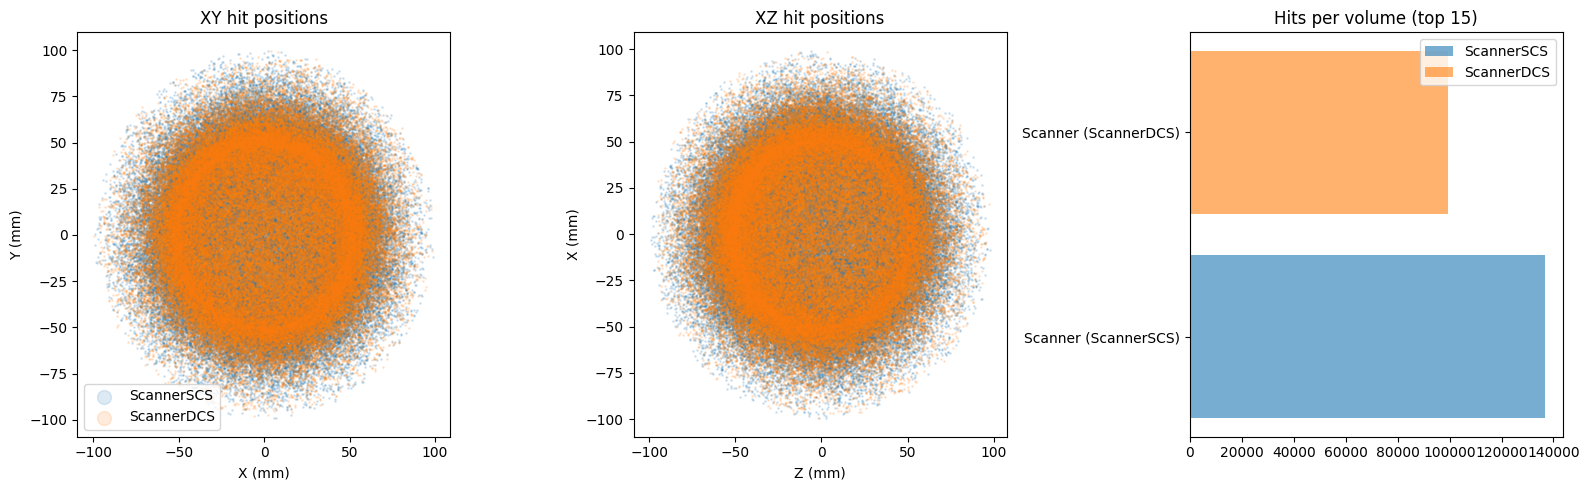

In [32]:
#spatial hit maps - scatter positio in scanner
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for name in ["ScannerSCS", "ScannerDCS"]:
    axes[0].scatter(dfs[name]["X_mm"], dfs[name]["Y_mm"], s=1, alpha=0.15, label=name)
axes[0].set_xlabel("X (mm)"); axes[0].set_ylabel("Y (mm)")
axes[0].set_title("XY hit positions")
axes[0].legend(markerscale=10)

for name in ["ScannerSCS", "ScannerDCS"]:
    axes[1].scatter(dfs[name]["Z_mm"], dfs[name]["X_mm"], s=1, alpha=0.15, label=name)
axes[1].set_xlabel("Z (mm)"); axes[1].set_ylabel("X (mm)")
axes[1].set_title("XZ hit positions")

# Hits per VolumeName
for name in ["ScannerSCS", "ScannerDCS"]:
    # Convert AwkwardExtensionArray to a standard Python list before creating a pandas Series
    counts = pd.Series(dfs[name]["VolumeName"].tolist()).value_counts().head(15)
    axes[2].barh(counts.index.astype(str) + f" ({name})", counts.values, alpha=0.6, label=name)
axes[2].set_title("Hits per volume (top 15)")
axes[2].legend()

plt.tight_layout()
plt.show()